# Serve Analysis — Exploratory Notebook

This notebook provides an interactive workflow for tennis serve velocity
estimation using manual 2-point calibration and template-based ball tracking.

**Intended iterative tuning workflow:**
1. Configure video path and known real-world distance
2. Set calibration points (two known-distance points in the video)
3. Set start frame and initial ball position post-impact
4. Adjust tracking parameters if needed
5. Run cells and inspect results
6. Re-run with adjusted parameters until satisfied

**Limitations (be honest):**
- Approximate single-view velocity estimate only
- Manual calibration prone to user measurement error
- Template matching can drift; adaptive update helps but is not perfect
- No 3D reconstruction, no spin estimation, no false precision

## Configuration

Set your parameters below. When `DEMO_MODE = True`, the notebook uses
synthetic data and skips video I/O for headless/CI execution.

In [27]:
# === GLOBAL SETTINGS ===
DEMO_MODE = False  # Set False to use real video (requires IMG_9259.MOV and manual inputs below)

# --- Video Configuration ---
# Path to your serve video. In DEMO_MODE this is ignored.
VIDEO_PATH = "../IMG_9259.MOV"

# Known real-world distance between your two calibration points (in meters)
# Example: if calibrating court lines that are 10m apart, set REAL_DISTANCE = 10.0
REAL_DISTANCE = 1.83  # meters

# --- Calibration Points (pixel coordinates from video) ---
# These are YOUR measured points. Replace with your actual measured positions.
# CAL_POINT_1 and CAL_POINT_2 should be two visually identifiable points
# with a known real-world distance between them.
CAL_POINT_1 = (1497, 2150)  # (x, y) in pixels — replace with your measurement
CAL_POINT_2 = (2287, 2150)  # (x, y) in pixels — replace with your measurement

# --- Tracking Parameters ---
# Frame to start tracking from (post-impact)
START_FRAME = 550

# Initial ball center position (x, y) in pixels at START_FRAME
# This must be a point where you can visually confirm the ball is present
INITIAL_CENTER = (2001, 1634)  # replace with your measurement

# Template matching parameters
TEMPLATE_SIZE = 13   # pixels — size of the template window
SEARCH_RADIUS = 100  # pixels — search radius around previous position
MAX_FRAMES = 3500      # maximum frames to track (None = until end)

# Velocity smoothing window
SMOOTHING_WINDOW = 3

print("Configuration loaded.")
print(f"  DEMO_MODE = {DEMO_MODE}")
if DEMO_MODE:
    print("  Running in DEMO MODE — using synthetic centers for headless execution.")
else:
    print(f"  Video: {VIDEO_PATH}")
    print(f"  Real distance between calibration points: {REAL_DISTANCE} m")
    print(f"  Calibration point 1: {CAL_POINT_1}")
    print(f"  Calibration point 2: {CAL_POINT_2}")
    print(f"  Start frame: {START_FRAME}, Initial ball center: {INITIAL_CENTER}")

Configuration loaded.
  DEMO_MODE = False
  Video: ../IMG_9259.MOV
  Real distance between calibration points: 1.83 m
  Calibration point 1: (1497, 2150)
  Calibration point 2: (2287, 2150)
  Start frame: 550, Initial ball center: (2001, 1634)


## Synthetic Demo Path (Headless Execution)

When `DEMO_MODE = True`, this cell generates synthetic ball centers
that simulate a serve flying across the frame at ~24 km/h (synthetic demo).

This allows the notebook to execute fully in CI/headless environments
without requiring manual clicks or the actual video file.

In [28]:
import numpy as np
import sys
sys.path.insert(0, "..")

from serve_analyzer.analysis import (
    compute_scale_factor,
    compute_velocity_series,
    get_video_info,
)

# Synthetic parameters
SYNTHETIC_FPS = 240.0
SYNTHETIC_CENTERS_COUNT = 48  # ~0.2 seconds at 240fps

# Generate synthetic centers simulating a ball traveling at ~24 km/h
# Actual: ~8.3 pixels/frame at scale_factor=0.00333 m/pixel → ~6.6 m/s → ~24 km/h
np.random.seed(42)
base_velocity_pix_per_frame = 8.3
noise = np.random.randn(SYNTHETIC_CENTERS_COUNT, 2) * 0.5

synthetic_centers = []
x, y = 100.0, 240.0
for i in range(SYNTHETIC_CENTERS_COUNT):
    synthetic_centers.append((x, y))
    x += base_velocity_pix_per_frame + noise[i, 0]
    y += noise[i, 1] * 0.3  # slight vertical jitter

# Use synthetic scale (same as would be computed from calibration)
synthetic_scale_factor = REAL_DISTANCE / np.sqrt(
    (CAL_POINT_2[0] - CAL_POINT_1[0])**2 + (CAL_POINT_2[1] - CAL_POINT_1[1])**2
)

print("Synthetic centers generated for demo.")
print(f"  FPS: {SYNTHETIC_FPS}")
print(f"  Frames: {len(synthetic_centers)}")
print(f"  Synthetic scale factor: {synthetic_scale_factor:.6f} m/pixel")

Synthetic centers generated for demo.
  FPS: 240.0
  Frames: 48
  Synthetic scale factor: 0.002316 m/pixel


## Real Video Execution Path

**Only run this section when `DEMO_MODE = False`** and you have
provided valid calibration points and initial ball position above.

**Manual steps required:**
1. Review the video in an external player to find two clear calibration
   points with a known real-world distance between them
2. Note their pixel coordinates and enter them in the configuration cell
3. Find the first frame after ball impact and note the frame number
4. Locate the ball center in that frame and enter the (x, y) coordinates

In [29]:
if not DEMO_MODE:
    print("Loading video info...")
    video_info = get_video_info(VIDEO_PATH)
    print(f"  FPS: {video_info['fps']:.2f}")
    print(f"  Resolution: {video_info['width']}x{video_info['height']}")
    print(f"  Total frames: {video_info['frame_count']}")
    print(f"  Duration: {video_info['duration_sec']:.2f} seconds")
else:
    print("Skipping real video load (DEMO_MODE=True).")
    video_info = {
        "fps": SYNTHETIC_FPS,
        "width": 1920,
        "height": 1080,
        "frame_count": SYNTHETIC_CENTERS_COUNT,
        "duration_sec": SYNTHETIC_CENTERS_COUNT / SYNTHETIC_FPS,
    }

Loading video info...
  FPS: 59.97
  Resolution: 3840x2160
  Total frames: 4133
  Duration: 68.92 seconds


## Scale Computation

Computes the pixel-to-meter scale factor from your two calibration points
and known real-world distance. This is the foundation of the velocity estimate.

In [30]:
# Compute scale factor
if DEMO_MODE:
    scale_factor = synthetic_scale_factor
    print(f"Using synthetic scale factor: {scale_factor:.6f} m/pixel")
else:
    scale_factor = compute_scale_factor(
        CAL_POINT_1,
        CAL_POINT_2,
        REAL_DISTANCE
    )
    pixel_dist = np.sqrt(
        (CAL_POINT_2[0] - CAL_POINT_1[0])**2 + (CAL_POINT_2[1] - CAL_POINT_1[1])**2
    )
    print(f"Scale factor: {scale_factor:.6f} m/pixel")
    print(f"  Pixel distance between calibration points: {pixel_dist:.1f} px")
    print(f"  Real-world distance: {REAL_DISTANCE} m")

Scale factor: 0.002316 m/pixel
  Pixel distance between calibration points: 790.0 px
  Real-world distance: 1.83 m


## Tracking

In DEMO_MODE: uses pre-generated synthetic centers.

In real mode: invokes `track_ball_template` from the serve_analyzer
package to track the ball from `START_FRAME` using the template
matching algorithm. This requires `INITIAL_CENTER` to be set correctly.

In [31]:
if DEMO_MODE:
    centers = synthetic_centers
    fps = SYNTHETIC_FPS
    print(f"Using synthetic centers ({len(centers)} frames)")
else:
    from serve_analyzer.analysis import track_ball_template
    
    print(f"Tracking ball starting at frame {START_FRAME}...")
    print(f"  Initial center: {INITIAL_CENTER}")
    print(f"  Template size: {TEMPLATE_SIZE}, Search radius: {SEARCH_RADIUS}")
    
    centers = track_ball_template(
        video_path=VIDEO_PATH,
        start_frame=START_FRAME,
        initial_center=INITIAL_CENTER,
        template_size=TEMPLATE_SIZE,
        search_radius=SEARCH_RADIUS,
        max_frames=MAX_FRAMES,
    )
    fps = video_info["fps"]
    print(f"Tracked {len(centers)} ball positions.")

print(f"FPS used for velocity: {fps:.2f}")

Tracking ball starting at frame 550...
  Initial center: (2001, 1634)
  Template size: 13, Search radius: 100
Tracked 3500 ball positions.
FPS used for velocity: 59.97


## Velocity Computation

Computes frame-to-frame speed, applies moving-average smoothing, and
produces a summary with max, mean, and median speeds in m/s and km/h.

In [33]:
speeds_mps, speeds_kmh, stats = compute_velocity_series(
    centers=centers,
    fps=fps,
    scale_factor=scale_factor,
    smoothing_window=SMOOTHING_WINDOW,
)

print("=" * 50)
print("VELOCITY ESTIMATION SUMMARY")
print("=" * 50)
print(f"Frames tracked:     {stats['frame_count']}")
print(f"Duration:           {stats['duration_sec']:.3f} seconds")
print(f"Smoothing window:  {SMOOTHING_WINDOW}")
print()
print(f"Maximum speed:      {stats['max_kmh']:.1f} km/h  ({stats['max_mps']:.2f} m/s)")
print(f"Mean speed:         {stats['mean_kmh']:.1f} km/h  ({stats['mean_mps']:.2f} m/s)")
print(f"Median speed:       {stats['median_kmh']:.1f} km/h  ({stats['median_mps']:.2f} m/s)")
print("=" * 50)

# Show per-frame speeds as a quick sanity check
print("\nPer-frame speeds (km/h) — first 10 frames:")
for i, spd in enumerate(speeds_kmh[:3500]):
    print(f"  Frame {i}: {spd:.1f} km/h")

VELOCITY ESTIMATION SUMMARY
Frames tracked:     3500
Duration:           58.343 seconds
Smoothing window:  3

Maximum speed:      54.6 km/h  (15.17 m/s)
Mean speed:         3.1 km/h  (0.86 m/s)
Median speed:       0.0 km/h  (0.00 m/s)

Per-frame speeds (km/h) — first 10 frames:
  Frame 0: 1.9 km/h
  Frame 1: 2.9 km/h
  Frame 2: 2.4 km/h
  Frame 3: 2.0 km/h
  Frame 4: 1.3 km/h
  Frame 5: 1.2 km/h
  Frame 6: 1.1 km/h
  Frame 7: 1.1 km/h
  Frame 8: 1.1 km/h
  Frame 9: 1.2 km/h
  Frame 10: 1.3 km/h
  Frame 11: 1.3 km/h
  Frame 12: 1.4 km/h
  Frame 13: 1.4 km/h
  Frame 14: 1.4 km/h
  Frame 15: 1.1 km/h
  Frame 16: 0.7 km/h
  Frame 17: 0.5 km/h
  Frame 18: 0.5 km/h
  Frame 19: 0.6 km/h
  Frame 20: 0.8 km/h
  Frame 21: 0.8 km/h
  Frame 22: 0.8 km/h
  Frame 23: 0.6 km/h
  Frame 24: 0.5 km/h
  Frame 25: 0.5 km/h
  Frame 26: 0.5 km/h
  Frame 27: 0.5 km/h
  Frame 28: 0.5 km/h
  Frame 29: 0.5 km/h
  Frame 30: 0.5 km/h
  Frame 31: 0.3 km/h
  Frame 32: 0.2 km/h
  Frame 33: 0.2 km/h
  Frame 34: 0.5 k

## Speed Profile Plot

Quick visualization of the speed profile across tracked frames.
In a real serve, you would typically see the ball accelerate through the
impact frame and then decelerate due to air resistance.

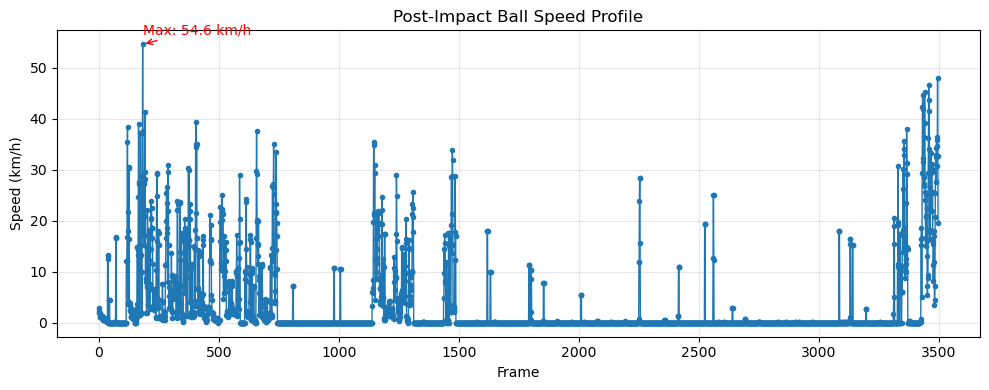

Plot saved to /tmp/speed_profile.png


In [34]:
%matplotlib inline
import matplotlib.pyplot as plt

frames = range(len(speeds_kmh))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(frames, speeds_kmh, marker="o", linewidth=1, markersize=3)
ax.set_xlabel("Frame")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Post-Impact Ball Speed Profile")
ax.grid(True, alpha=0.3)

# Mark max speed
max_idx = int(np.argmax(speeds_kmh))
ax.annotate(
    f"Max: {speeds_kmh[max_idx]:.1f} km/h",
    xy=(max_idx, speeds_kmh[max_idx]),
    xytext=(max_idx + 2, speeds_kmh[max_idx] + 2),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
)

plt.tight_layout()
plt.show()
plt.savefig("/tmp/speed_profile.png", dpi=100)
plt.close()
print("Plot saved to /tmp/speed_profile.png")

## Parameter Tuning Notes

If results look wrong, here are the most impactful parameters to tune:

| Parameter | What to adjust | Symptoms of wrong value |
|---|---|---|
| `REAL_DISTANCE` | Re-measure calibration points | Scale too high/low affects all velocities proportionally |
| `CAL_POINT_1`, `CAL_POINT_2` | Use clearer reference points | Scale error if points are ambiguous |
| `START_FRAME` | Move earlier/later | Miss the serve if too late; noisy if too early |
| `INITIAL_CENTER` | Click the ball more carefully | Tracking starts from wrong position |
| `TEMPLATE_SIZE` | Increase if ball looks small; decrease if crowded | Tracking drift or mismatch |
| `SEARCH_RADIUS` | Increase if ball moves fast between frames | Ball goes out of search window |
| `SMOOTHING_WINDOW` | Increase to reduce jitter; decrease to preserve peaks | Over-smoothed or noisy |

**Iterative workflow:** Adjust one parameter at a time and re-run the
tracking and velocity cells to see the effect.

## Limitations (be honest with yourself)

- This tool gives an **approximate** velocity from a single lateral view
- Perspective error increases with ball height above the calibration plane
- Template matching can drift or lose the ball in cluttered backgrounds
- No spin estimation; no 3D reconstruction; no magic
- Calibration point measurement error directly affects all velocity values

**Use this as a coarse sanity check**, not a precise measurement device.